In [3]:
!pip install pandas numpy matplotlib seaborn xgboost fbprophet tensorflow 

  Using cached fbprophet-0.7.1.tar.gz (64 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached cmdstanpy-0.9.5-py3-none-any.whl.metadata (2.9 kB)
  Using cached pystan-3.10.1-py3-none-any.whl.metadata (3.6 kB)
  Using cached LunarCalendar-0.0.9-py2.py3-none-any.whl.metadata (6.3 kB)
  Using cached convertdate-2.4.1-py3-none-any.whl.metadata (9.7 kB)
  Using cached setuptools_git-1.2-py2.py3-none-any.whl.metadata (5.8 kB)
  Using cached PyMeeus-0.5.12.tar.gz (5.8 MB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached ephem-4.2.1-cp313-cp313-win_amd64.whl.metadata (6.5 kB)
  Using cached clikit-0.6.2-py2.py3-none-any.whl.metadata (1.6 kB)
INFO: pip is looking at multiple versions of pystan to determine which version is compatible with other requirements. This could take a while.
  Using cached pystan-3.10.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached

  DEPRECATION: Building 'fbprophet' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'fbprophet'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  error: subprocess-exited-with-error
  
  python setup.py bdist_wheel did not run successfully.
  exit code: 1
  
  [101 lines of output]
  C:\Users\asus\AppData\Local\Temp\pip-install-0pzrfcay\fbprophet_252d8d87c55e44f8a53a1e32e059022e\setup.py:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
    from pkg_resources import (
  C:\Users\asus\AppData\Local\Temp\pip-install-0pzrfcay\fbprophet_252d8d87c55e44f8a53a1e32e059022e\setup.py:19: SetuptoolsDeprecationWar

In [4]:
!pip install numpy openpyxl

In [5]:
import pandas as pd
import numpy as np
import openpyxl

In [6]:
data=pd.read_excel("data.xlsx")
print(data.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [7]:
display(data.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
data.info() #veri seti bilgisi

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [9]:
data.columns=['FaturaNo', 'StokKodu', 'UrunAciklamasi', 'Adet', 'FaturaTarihi', 'BirimFiyat', 'MusteriID', 'Ulke']

ozet=pd.DataFrame({
    'degisken ad': data.columns,
    'benzersiz deger sayisi': [data[col].nunique() for col in data.columns],
    'veri tipi': data.dtypes.values })

display(ozet)

,degisken ad,benzersiz deger sayisi,veri tipi
0,FaturaNo,25900,object
1,StokKodu,4070,object
2,UrunAciklamasi,4223,object
3,Adet,722,int64
4,FaturaTarihi,23260,datetime64[ns]
5,BirimFiyat,1630,float64
6,MusteriID,4372,float64
7,Ulke,38,object


In [10]:
# Sayısal değişkenler için
data.describe()

,Adet,FaturaTarihi,BirimFiyat,MusteriID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [11]:
data.isnull().sum()

FaturaNo               0
StokKodu               0
UrunAciklamasi      1454
Adet                   0
FaturaTarihi           0
BirimFiyat             0
MusteriID         135080
Ulke                   0
dtype: int64

In [12]:
display(data.head())

,FaturaNo,StokKodu,UrunAciklamasi,Adet,FaturaTarihi,BirimFiyat,MusteriID,Ulke
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [13]:
eksik_veri=pd.DataFrame({
  'Eksik Sayısı': data.isnull().sum(),
   'Oran': (data.isnull().sum()/len(data)) * 100
})
print(eksik_veri[eksik_veri['Eksik Sayısı']>0])

                Eksik Sayısı       Oran
UrunAciklamasi          1454   0.268311
MusteriID             135080  24.926694


In [14]:
#'C' İÇERMEYENLERİ (İptal edilmeyenleri) al
data = data[~data['FaturaNo'].str.contains('C', na=False)] #iptal edilen faturalar
#negatif ve sıfır degerler
data=data[data['Adet']>0] 
data=data[data['BirimFiyat']>0]

In [15]:
#Eksik ürünker (daha temiz bir veri seti için direkt silelim çünkü musteriID gereksiz açıklaması az)
data = data.drop(columns=['MusteriID'])
data = data.dropna(subset=['UrunAciklamasi'])


In [16]:
data.isnull().sum()

FaturaNo          0
StokKodu          0
UrunAciklamasi    0
Adet              0
FaturaTarihi      0
BirimFiyat        0
Ulke              0
dtype: int64

Ürün Davranış Analizi Yöntemleri
ABC Analizi (Pareto Prensibi): Ürünleri toplam ciroya katkılarına göre %80 (A), %15 (B) ve %5 (C) şeklinde nasıl sınıflandırıldığı


In [17]:
#ToplamFiyat = Adet × BirimFiyat (Bagimli degisken) feature engeering
data['Toplam Fiyat']=data['Adet']*data['BirimFiyat']

In [18]:
# Çarpıklık (skewness)
data[['Adet', 'Toplam Fiyat']].skew()

Adet            471.727716
Toplam Fiyat    506.706012
dtype: float64

In [19]:
print(data)

       FaturaNo StokKodu                       UrunAciklamasi  Adet  \
0        536365   85123A   WHITE HANGING HEART T-LIGHT HOLDER     6   
1        536365    71053                  WHITE METAL LANTERN     6   
2        536365   84406B       CREAM CUPID HEARTS COAT HANGER     8   
3        536365   84029G  KNITTED UNION FLAG HOT WATER BOTTLE     6   
4        536365   84029E       RED WOOLLY HOTTIE WHITE HEART.     6   
...         ...      ...                                  ...   ...   
541904   581587    22613          PACK OF 20 SPACEBOY NAPKINS    12   
541905   581587    22899         CHILDREN'S APRON DOLLY GIRL      6   
541906   581587    23254        CHILDRENS CUTLERY DOLLY GIRL      4   
541907   581587    23255      CHILDRENS CUTLERY CIRCUS PARADE     4   
541908   581587    22138        BAKING SET 9 PIECE RETROSPOT      3   

              FaturaTarihi  BirimFiyat            Ulke  Toplam Fiyat  
0      2010-12-01 08:26:00        2.55  United Kingdom         15.30  
1    

In [20]:
data['FaturaTarihi'] = pd.to_datetime(data['FaturaTarihi']) #tarih formatı

Veri setinde yer alan ‘Adet’ ve ‘BirimFiyat’ değişkenleri kullanılarak her bir işlem için toplam satış tutarı hesaplanmıştır. Bu doğrultuda ‘ToplamFiyat’ değişkeni oluşturulmuş ve analizlerde bağımlı değişken olarak kullanılmıştır.

In [21]:

data['Tarih'] = data['FaturaTarihi'].dt.date
data['Yil'] = data['FaturaTarihi'].dt.year
data['Ay'] = data['FaturaTarihi'].dt.month

# 2. Sonra günlük toplam satışı hesapla
gunluk_satis = data.groupby('Tarih')['Toplam Fiyat'].sum().reset_index()

# 3. Sonuçları kontrol et
print(gunluk_satis.head())

        Tarih  Toplam Fiyat
0  2010-12-01      58960.79
1  2010-12-02      47748.38
2  2010-12-03      46943.71
3  2010-12-05      31774.95
4  2010-12-06      54830.46


array([[<Axes: title={'center': 'Adet'}>,
        <Axes: title={'center': 'BirimFiyat'}>],
       [<Axes: title={'center': 'Toplam Fiyat'}>, <Axes: >]], dtype=object)

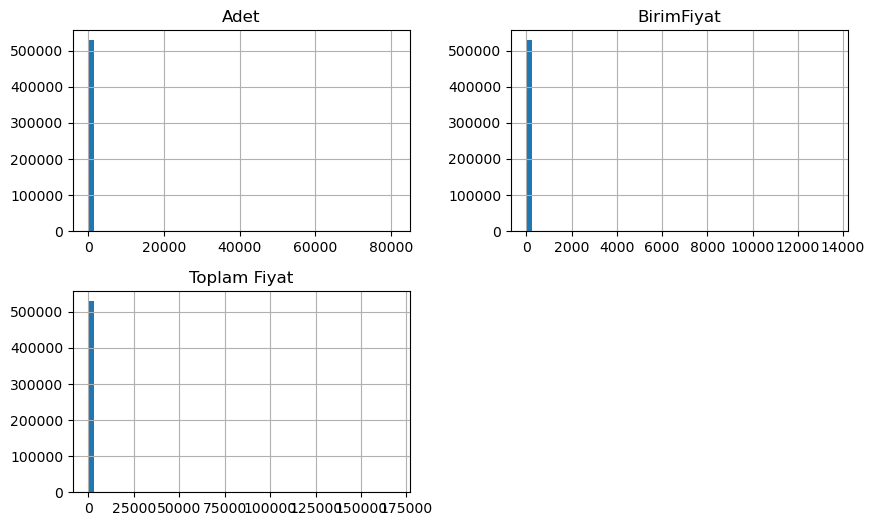

In [22]:
data[['Adet', 'BirimFiyat', 'Toplam Fiyat']].hist(bins=50, figsize=(10,6)) #dagılım outlier

<Axes: >

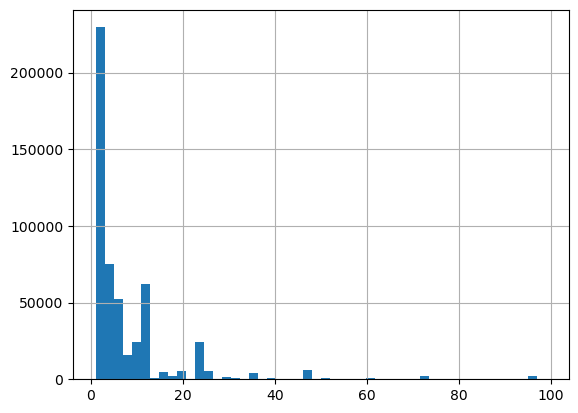

In [23]:
data[data['Adet'] < 100]['Adet'].hist(bins=50)

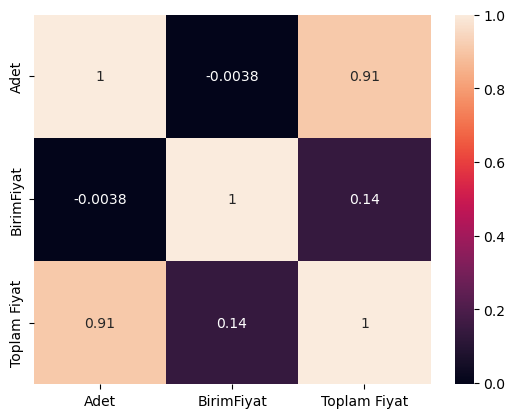

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(data[['Adet', 'BirimFiyat', 'Toplam Fiyat']].corr(), annot=True)
plt.show()

<Axes: >

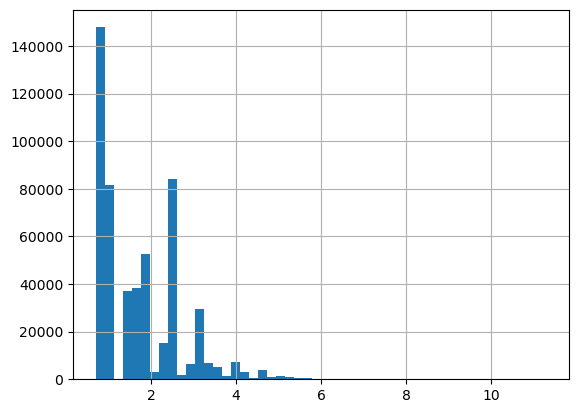

In [25]:
# Veriyi logaritmik formata çevir 
data['Log_Adet'] = np.log1p(data['Adet'])
data['Log_Adet'].hist(bins=50) 

In [26]:
#feature engineering
ts=gunluk_satis.set_index('Tarih').copy() #günlük satışları time series adıyla işle
for i in [1,7,14]:
    ts[f'lag_{i}']=ts['Toplam Fiyat'].shift(i) #gecikmeli deger(lags) geçmiş satışlar geleceği söyler

ts.index=pd.to_datetime(ts.index)  #takvim özellikleri
ts['gun']=ts.index.day
ts['haftanin_gunu']=ts.index.dayofweek
ts['ay_sonu']=ts.index.is_month_end.astype(int)

ts=ts.dropna() #boş satır temizleme

11:15:28 - cmdstanpy - INFO - Chain [1] start processing
11:15:28 - cmdstanpy - INFO - Chain [1] done processing


Prophet R2 Skoru: -0.7403
Prophet MAE: 24896.83


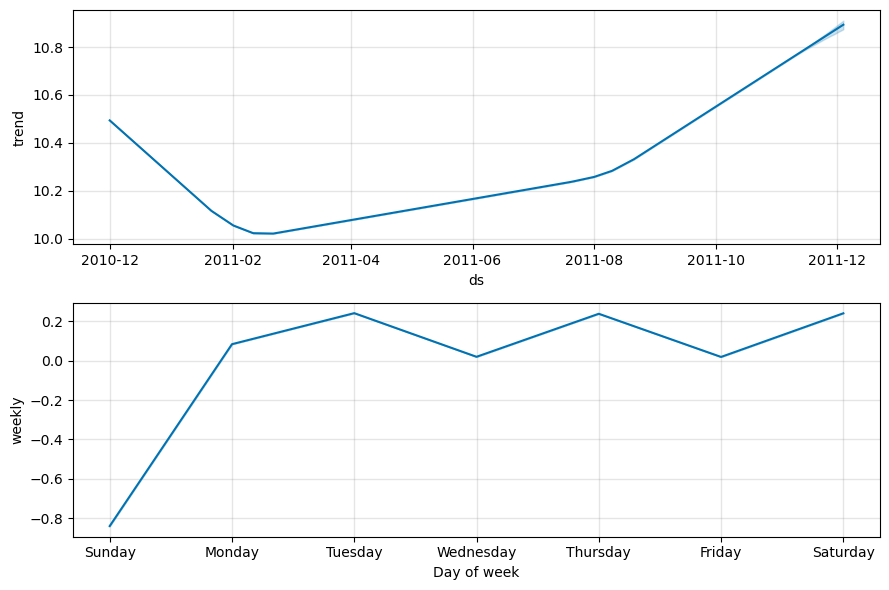

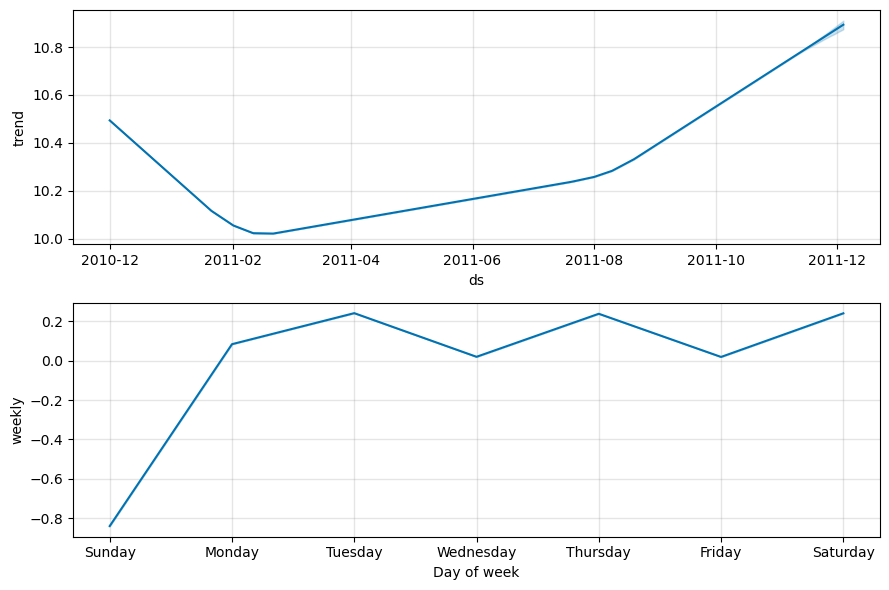

In [27]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# Şimdi Prophet kodunu tekrar çalıştırabilirsin
# 1. Veriyi Hazırlama
# Prophet sütun isimlerinin mutlaka 'ds' (tarih) ve 'y' (hedef) olmasını ister.
prophet_df = daily[['Date', 'TotalAmount']].copy()
prophet_df.columns = ['ds', 'y']

# Prophet logaritmik veride trendi daha iyi yakalar
prophet_df['y'] = np.log1p(prophet_df['y'])

# Eğitim ve test ayrımı (Son 30 günü test yapalım)
train_prophet = prophet_df.iloc[:-30]
test_prophet = prophet_df.iloc[-30:]

# 2. Modeli Tanımlama ve Eğitme
# Veri seti küçük olduğu için changepoint_prior_scale'i düşük tutarak ezberlemeyi önlüyoruz.
model_prophet = Prophet(
    yearly_seasonality=False, # 1 yıllık veride yıllık mevsimsellik hatalı olabilir
    weekly_seasonality=True,  # Haftalık döngüler (hafta sonu etkisi) önemlidir
    daily_seasonality=False,
    changepoint_prior_scale=0.05 
)

# E-ticaret için ay sonu etkisini ekleyelim (Extra Regressor)
# Not: Eğitim setinde 'is_month_end' bilgisini ts tablosundan çekebilirsin.
# model_prophet.add_country_holidays(country_name='UK') # Veri seti UK merkezli olduğu için

model_prophet.fit(train_prophet)

# 3. Gelecek Tahmini Oluşturma
future = model_prophet.make_future_dataframe(periods=30)
forecast = model_prophet.predict(future)

# 4. Tahminleri Gerçek Değerlere Döndürme
# Logaritmik tahmini expm1 ile geri çeviriyoruz
y_pred = np.expm1(forecast['yhat'].iloc[-30:]).values
y_true = np.expm1(test_prophet['y']).values

# 5. Performans Ölçümü
print(f"Prophet R2 Skoru: {r2_score(y_true, y_pred):.4f}")
print(f"Prophet MAE: {mean_absolute_error(y_true, y_pred):.2f}")

# 6. Bileşen Analizi (Trend ve Haftalık Döngüyü Görselleştirme)
model_prophet.plot_components(forecast)